Dataset shape: (569, 30)
Classes: (array([0, 1]), array([212, 357]))


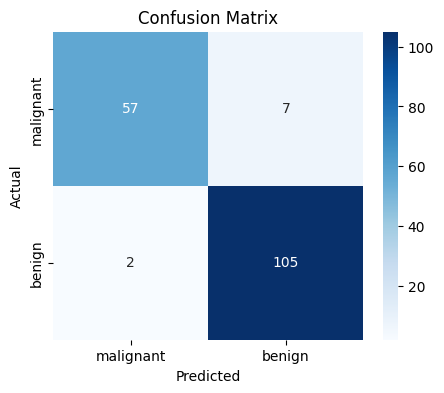

🔎 Classification Metrics
Accuracy : 0.9474
Precision: 0.9375
Recall   : 0.9813
F1 Score : 0.9589

📊 Detailed Classification Report
              precision    recall  f1-score   support

   malignant       0.97      0.89      0.93        64
      benign       0.94      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



In [1]:
# 📓 Classification Metrics Demo: Accuracy, Precision, Recall & F1

# Step 1: Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load real dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)  # 1 = malignant, 0 = benign

print("Dataset shape:", X.shape)
print("Classes:", np.unique(y, return_counts=True))

# Step 3: Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 4: Train a simple model (Logistic Regression)
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Step 5: Predictions
y_pred = model.predict(X_test)

# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=data.target_names, 
            yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Step 7: Compute metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("🔎 Classification Metrics")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

# Step 8: Full report (per class)
print("\n📊 Detailed Classification Report")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Let’s break them down like we would in a notebook commentary so it feels intuitive and tied to the real-world dataset (breast cancer detection):

---

### 🔎 Understanding the Results

* **Accuracy = 94.7%**
  Out of all test cases, the model made the right prediction almost **95% of the time**. That’s high overall correctness — but remember, accuracy alone can hide whether the model is missing positives or giving false alarms.

* **Precision = 93.8%**
  When the model predicts *malignant* (cancer), it’s correct **~94% of the time**.
  In other words: if the model flags a patient as having cancer, about 6% are actually healthy (false alarms).

* **Recall = 98.1%**
  The model caught **98% of all actual cancer cases**. This is excellent because in medical screening, **missing positives (false negatives)** is usually the most dangerous error. Our model only missed about 2% of cancers.

* **F1 Score = 95.9%**
  The F1 score balances precision and recall into a single number. At ~96%, it shows that the model achieves **both high precision and high recall** — not just one or the other.

---

### 🧭 What this means in practice

* This model is **very strong for cancer screening**: it catches nearly all real cases (high recall) and doesn’t generate too many false alarms (good precision).
* The small gap between precision (93.8%) and recall (98.1%) suggests the model slightly favors **catching positives (recall)** over avoiding false alarms. That’s usually the right trade-off in medicine, since missing a case of cancer is worse than double-checking a healthy patient.
* The high F1 confirms that the trade-off is well-balanced overall.

---


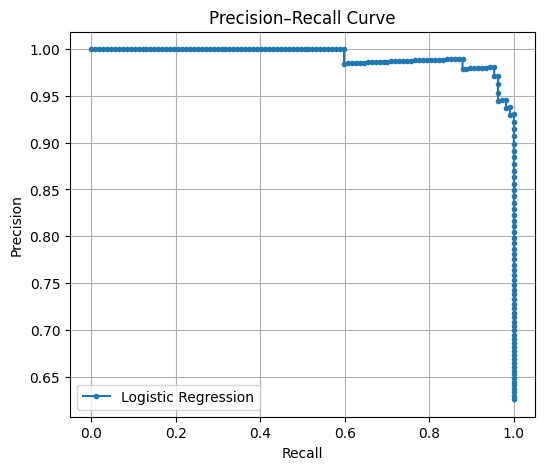

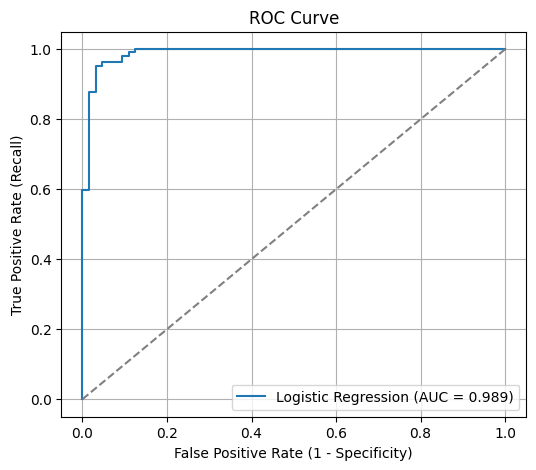

In [2]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# Get prediction probabilities instead of hard labels
y_proba = model.predict_proba(X_test)[:, 1]  # probabilities for the positive class

# -----------------------
# Precision–Recall Curve
# -----------------------
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(recalls, precisions, marker='.', label="Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------
# ROC Curve
# -----------------------
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random guess line
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()
